# PyTorch (continued)

In [1]:
%matplotlib inline
import torch
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

# Check available hardware
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU is available, using {device}')
elif torch.mps.is_available():
    device = torch.device('mps')
    print(f'Apple Metal Performance Shaders framework is available, using {device}')
else:
    device = torch.device('cpu')
    print(f'Hardware acceleration not available, using {device}')

Apple Metal Performance Shaders framework is available, using mps


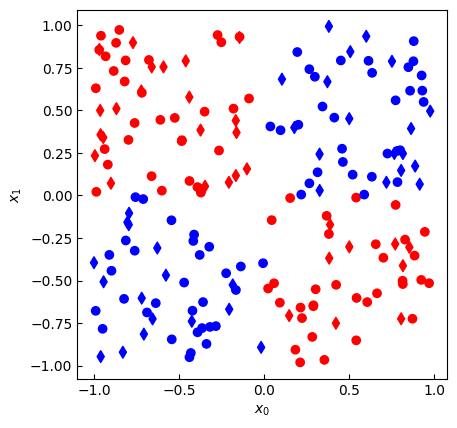

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

def make_xor_dataset(N=100, random_seed=42):
    np.random.seed(random_seed)
    X = 2 * np.random.uniform(size=(N, 2)).astype(np.float32) - 1
    y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)
    y = np.where(y, 1, 0)
    return X, y

X, y = make_xor_dataset(N=128, random_seed=42)
X_test, y_test = make_xor_dataset(N=64, random_seed=1)

ax = plt.figure().gca()
ax.scatter(X[:, 0], X[:, 1], c=y, marker='o', cmap='bwr')
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='d', cmap='bwr')
ax.set(xlabel='$x_0$', ylabel='$x_1$', aspect='equal');

In [3]:
from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
train_dataset, val_dataset = random_split(dataset, (0.8, 0.2))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=32)
val_loader = DataLoader(val_dataset, batch_size=32)

Train: 103, Val: 25, Test: 64


In [32]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(2, 2),
    nn.Softmax(),
).to(device)

loss_fn = nn.CrossEntropyLoss() # Binary cross entropy
optimizer = torch.optim.SGD(model.parameters(), lr=5e-2)


In [33]:
def train(model, loss_fn, optimizer, train_loader, val_loader, max_epochs=200):
    train_loss, train_acc = [], []
    val_loss, val_acc = [], []

    for epoch in range(max_epochs):
        train_loss.append(0)
        train_acc.append(0)
        for x, y, in train_loader:
            x = x.to(device)
            y = y.to(device)

            y_pred = model(x)

            loss = loss_fn(y_pred, y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_loss[-1] += loss.item() * x.shape[0]
            train_acc[-1]  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

        train_loss[-1] /= len(train_dataset)
        train_acc[-1] /= len(train_dataset)

        val_loss.append(0)
        val_acc.append(0)
        with torch.no_grad():
            for x, y, in val_loader:
                x = x.to(device)
                y = y.to(device)

                y_pred = model(x)
                loss = loss_fn(y_pred, y)

                val_loss[-1] += loss.item() * x.shape[0]
                val_acc[-1]  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

            val_loss[-1] /= len(val_dataset)
            val_acc[-1] /= len(val_dataset)

    return model, (train_loss, train_acc, val_loss, val_acc)

model, model_stats= train(model, loss_fn, optimizer, train_loader, val_loader)

/Users/jonathancolen/miniconda3/envs/pytorch/lib/python3.10/site-packages/torch/nn/modules/module.py:1778: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


<Axes: >

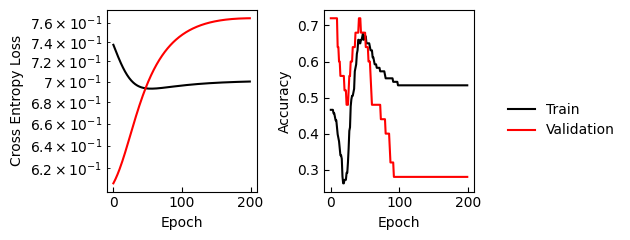

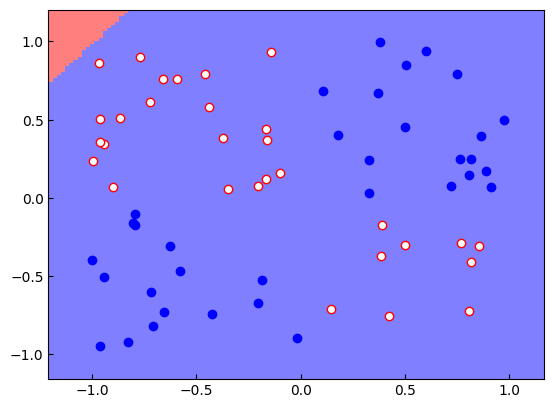

In [34]:
def loss_accuracy_plot(train_loss, train_acc, val_loss, val_acc):
    fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

    ax[0].plot(train_loss, color='black', label='Train')
    ax[0].plot(val_loss, color='red', label='Validation')
    ax[0].set(xlabel='Epoch', ylabel='Cross Entropy Loss', yscale='log')

    ax[1].plot(train_acc, color='black', label='Train')
    ax[1].plot(val_acc, color='red', label='Validation')
    ax[1].set(xlabel='Epoch', ylabel='Accuracy')

    fig.legend(*ax[1].get_legend_handles_labels(), 
            loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)
    return fig

from matplotlib.colors import ListedColormap
def plot_decision_boundary(ax, X, y, model, d=0.02, colors=['blue', 'red']):
    x1, x2 = np.meshgrid(
        np.arange(X[:, 0].min()-10*d, X[:, 0].max()+10*d, d),
        np.arange(X[:, 1].min()-10*d, X[:, 1].max()+10*d, d),
    )
    with torch.no_grad():
        x_grid = np.stack([x1.ravel(), x2.ravel()]).T
        x_grid = torch.from_numpy(x_grid.astype(np.float32)).to(device)
        y_model = model(x_grid).cpu().numpy()
        y_model = np.argmax(y_model, axis=-1)
        y_model = y_model.reshape(x1.shape)

        y_pred = model(torch.from_numpy(X).to(device)).cpu().numpy()
        y_pred = np.argmax(y_pred, axis=1)

        pred_mask = y_pred == y

    cmap = ListedColormap(colors)
    im=ax.pcolormesh(x1, x2, y_model, alpha=0.5, cmap=cmap)
    for ii, label in enumerate(np.unique(y)):
        label_mask = y == label
        ax.scatter(X[label_mask & pred_mask, 0], X[label_mask & pred_mask, 1], 
                   facecolor=colors[label], edgecolor=colors[label])
        ax.scatter(X[label_mask & ~pred_mask, 0], X[label_mask & ~pred_mask, 1], 
                   facecolor='white', edgecolor=colors[label])
    return ax

loss_accuracy_plot(*model_stats)
plt.tight_layout()

ax = plt.figure().gca()
plot_decision_boundary(ax, X_test, y_test, model)

<Axes: >

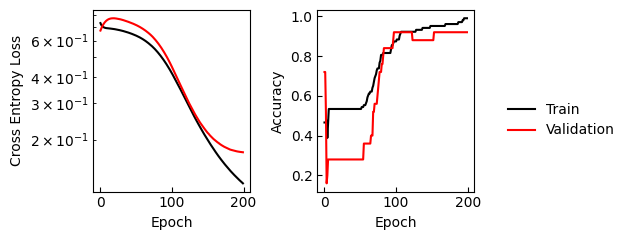

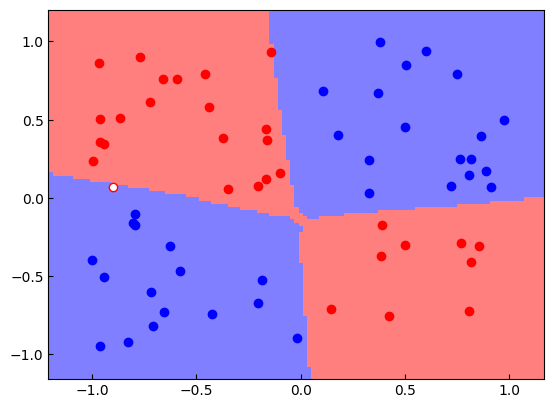

In [35]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 2),
).to(device)

loss_fn = nn.CrossEntropyLoss() # cross entropy
optimizer = torch.optim.SGD(model.parameters(), lr=5e-2)

model, model_stats= train(model, loss_fn, optimizer, train_loader, val_loader)

loss_accuracy_plot(*model_stats)
plt.tight_layout()

ax = plt.figure().gca()
plot_decision_boundary(ax, X_test, y_test, model)

## Customizing model behavior

In [68]:
class NoisyLinear(nn.Module):
    """ Layers also extend nn.Module """
    def __init__(self, input_size, output_size, noise_std=0.05):
        super().__init__()
        self.w = nn.Parameter(
            torch.FloatTensor(input_size, output_size)
        )
        nn.init.xavier_uniform_(self.w)

        self.b = nn.Parameter(
            torch.FloatTensor(output_size,).fill_(0)
        )

        self.noise_std = noise_std

    def forward(self, x, training=False):
        if training:
            x_new = x + torch.normal(0., self.noise_std, size=x.shape, device=x.device)
        else:
            x_new = x

        return x_new @ self.w + self.b

class NoisyModel(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=16, output_size=2):
        super().__init__()
        self.hidden_layer1 = NoisyLinear(input_size, hidden_size)
        self.hidden_layer2 = torch.nn.Linear(hidden_size, hidden_size)
        self.output_layer = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x, training=False):
        x = self.hidden_layer1(x, training=training)
        x = torch.nn.functional.relu(x)
        x = self.hidden_layer2(x)
        x = torch.nn.functional.relu(x)
        x = self.output_layer(x)
        return x

model = NoisyModel().to(device)
model

NoisyModel(
  (hidden_layer1): NoisyLinear()
  (hidden_layer2): Linear(in_features=16, out_features=16, bias=True)
  (output_layer): Linear(in_features=16, out_features=2, bias=True)
)

In [69]:
def train(model, loss_fn, optimizer, train_loader, val_loader, max_epochs=200):
    train_loss, train_acc = [], []
    val_loss, val_acc = [], []

    for epoch in range(max_epochs):
        train_loss.append(0)
        train_acc.append(0)
        for x, y, in train_loader:
            x = x.to(device)
            y = y.to(device)

            y_pred = model(x, training=True)

            loss = loss_fn(y_pred, y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_loss[-1] += loss.item() * x.shape[0]
            train_acc[-1]  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

        train_loss[-1] /= len(train_dataset)
        train_acc[-1] /= len(train_dataset)

        val_loss.append(0)
        val_acc.append(0)
        with torch.no_grad():
            for x, y, in val_loader:
                x = x.to(device)
                y = y.to(device)

                y_pred = model(x, training=False)
                loss = loss_fn(y_pred, y)

                val_loss[-1] += loss.item() * x.shape[0]
                val_acc[-1]  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

            val_loss[-1] /= len(val_dataset)
            val_acc[-1] /= len(val_dataset)

    return model, (train_loss, train_acc, val_loss, val_acc)

model = model.to(device)
loss_fn = nn.CrossEntropyLoss() # cross entropy
optimizer = torch.optim.SGD(model.parameters(), lr=5e-2)
model, model_stats = train(model, loss_fn, optimizer, train_loader, val_loader)

<Axes: >

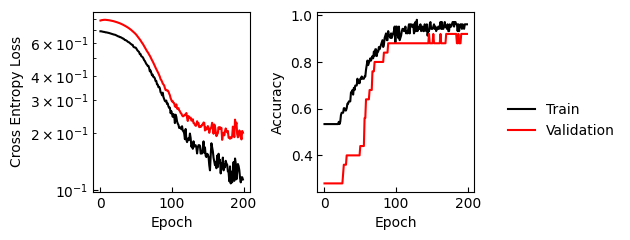

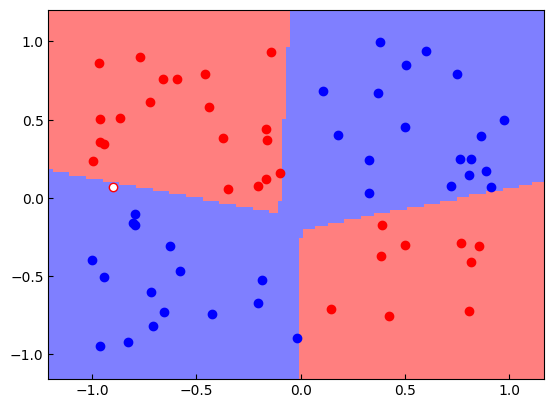

In [70]:
loss_accuracy_plot(*model_stats)
plt.tight_layout()

ax = plt.figure().gca()
plot_decision_boundary(ax, X_test, y_test, model)

## MNIST Classification

In [79]:
import torchvision
from torchvision.transforms import v2

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
train_ds = torchvision.datasets.MNIST(
    root='~/',
    train=True,
    transform=transform,
    download=True
)

test_ds = torchvision.datasets.MNIST(
    root='~/',
    train=False,
    transform=transform,
    download=False
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

In [80]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(train_ds[0][0].numel(), 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)
model = model.to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=32, bias=True)
  (2): ReLU()
  (3): Linear(in_features=32, out_features=32, bias=True)
  (4): ReLU()
  (5): Linear(in_features=32, out_features=10, bias=True)
)

In [84]:
for epoch in range(20):
    train_acc = 0.
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        y_pred = model(x_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        num_correct = (torch.argmax(y_pred, dim=1) == y_batch).float().sum()
        train_acc += num_correct.item()

    train_acc /= len(train_ds)
    print(f'Epoch {epoch}: Accuracy = {train_acc:g}')

Epoch 0: Accuracy = 0.80345
Epoch 1: Accuracy = 0.906983
Epoch 2: Accuracy = 0.918833
Epoch 3: Accuracy = 0.926883
Epoch 4: Accuracy = 0.932867
Epoch 5: Accuracy = 0.93865
Epoch 6: Accuracy = 0.9423
Epoch 7: Accuracy = 0.946433
Epoch 8: Accuracy = 0.9493
Epoch 9: Accuracy = 0.952333
Epoch 10: Accuracy = 0.955267
Epoch 11: Accuracy = 0.957133
Epoch 12: Accuracy = 0.958867
Epoch 13: Accuracy = 0.960267
Epoch 14: Accuracy = 0.96235
Epoch 15: Accuracy = 0.963817
Epoch 16: Accuracy = 0.96545
Epoch 17: Accuracy = 0.9669
Epoch 18: Accuracy = 0.967917
Epoch 19: Accuracy = 0.969283
